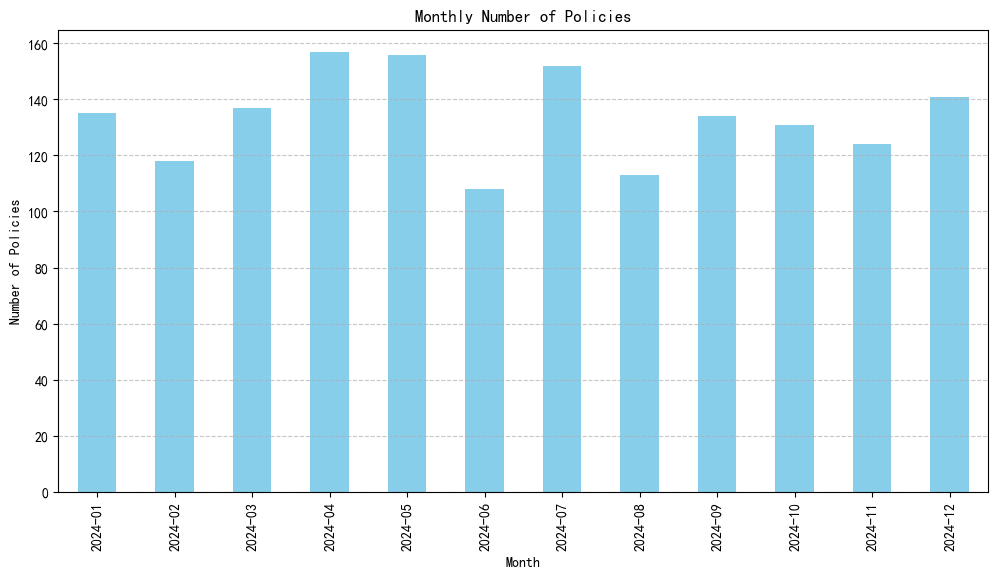

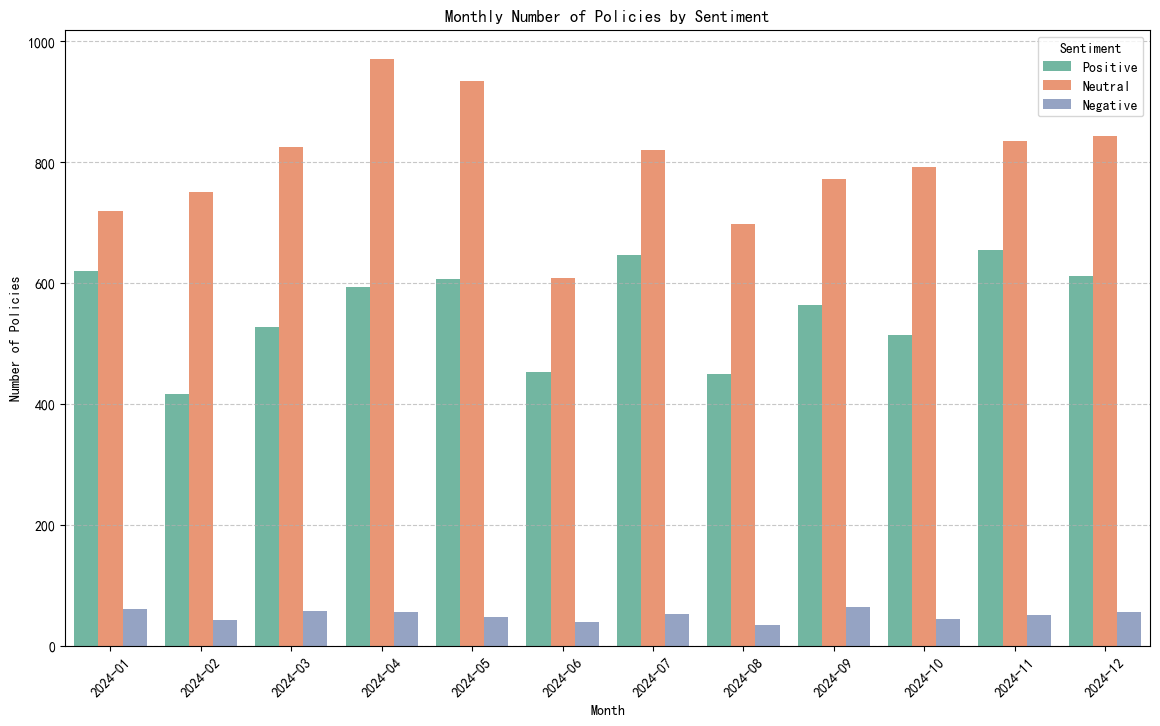

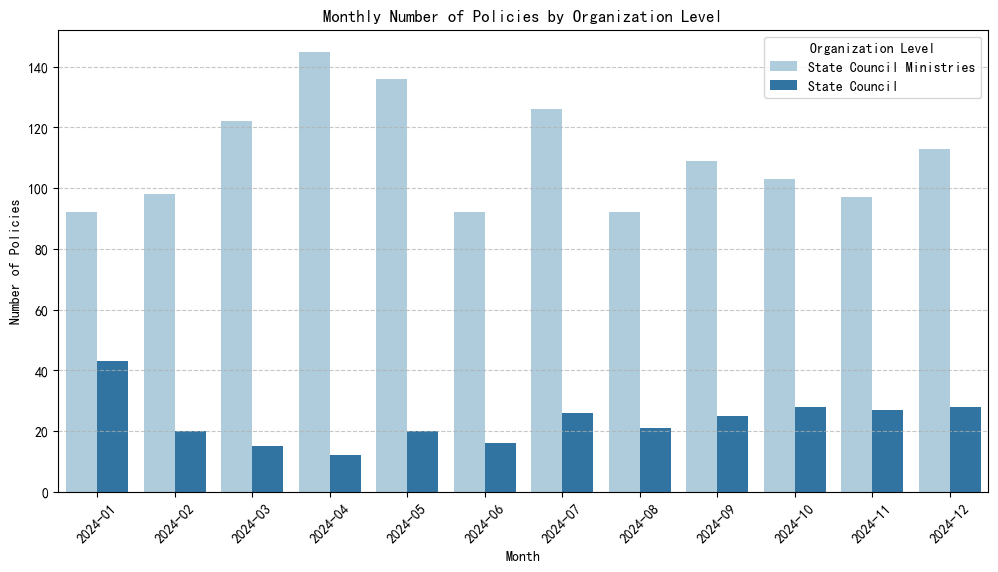

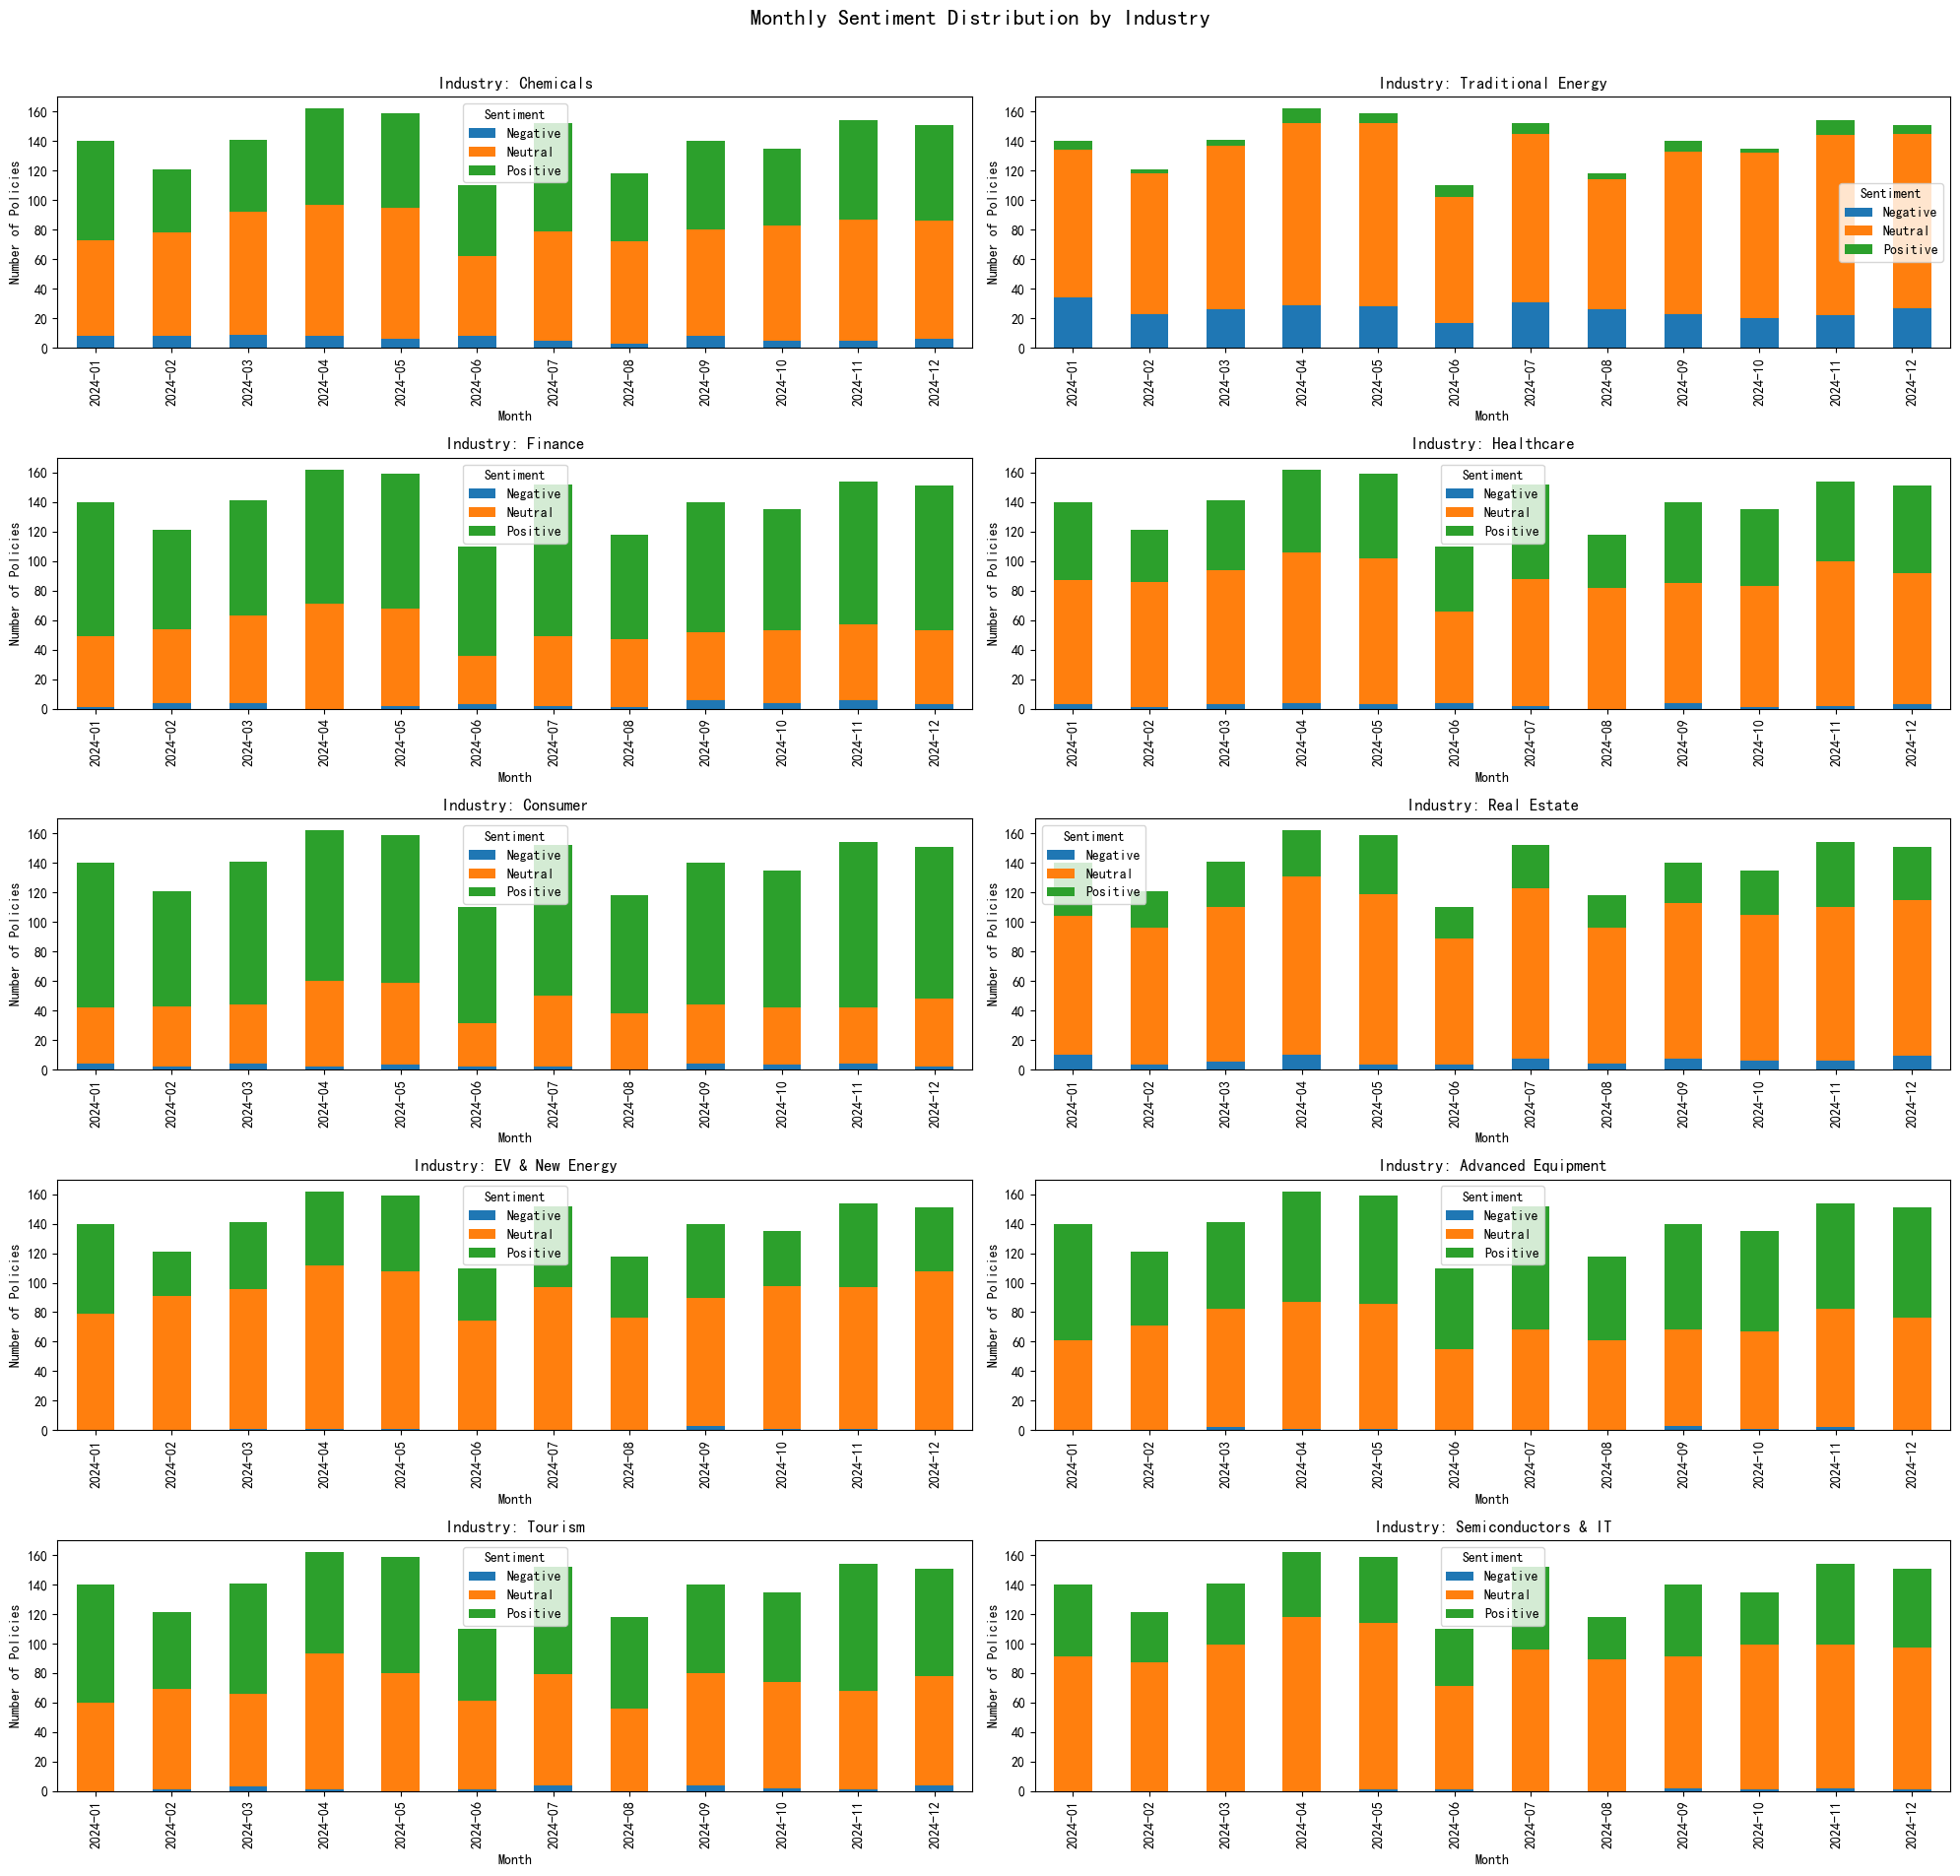

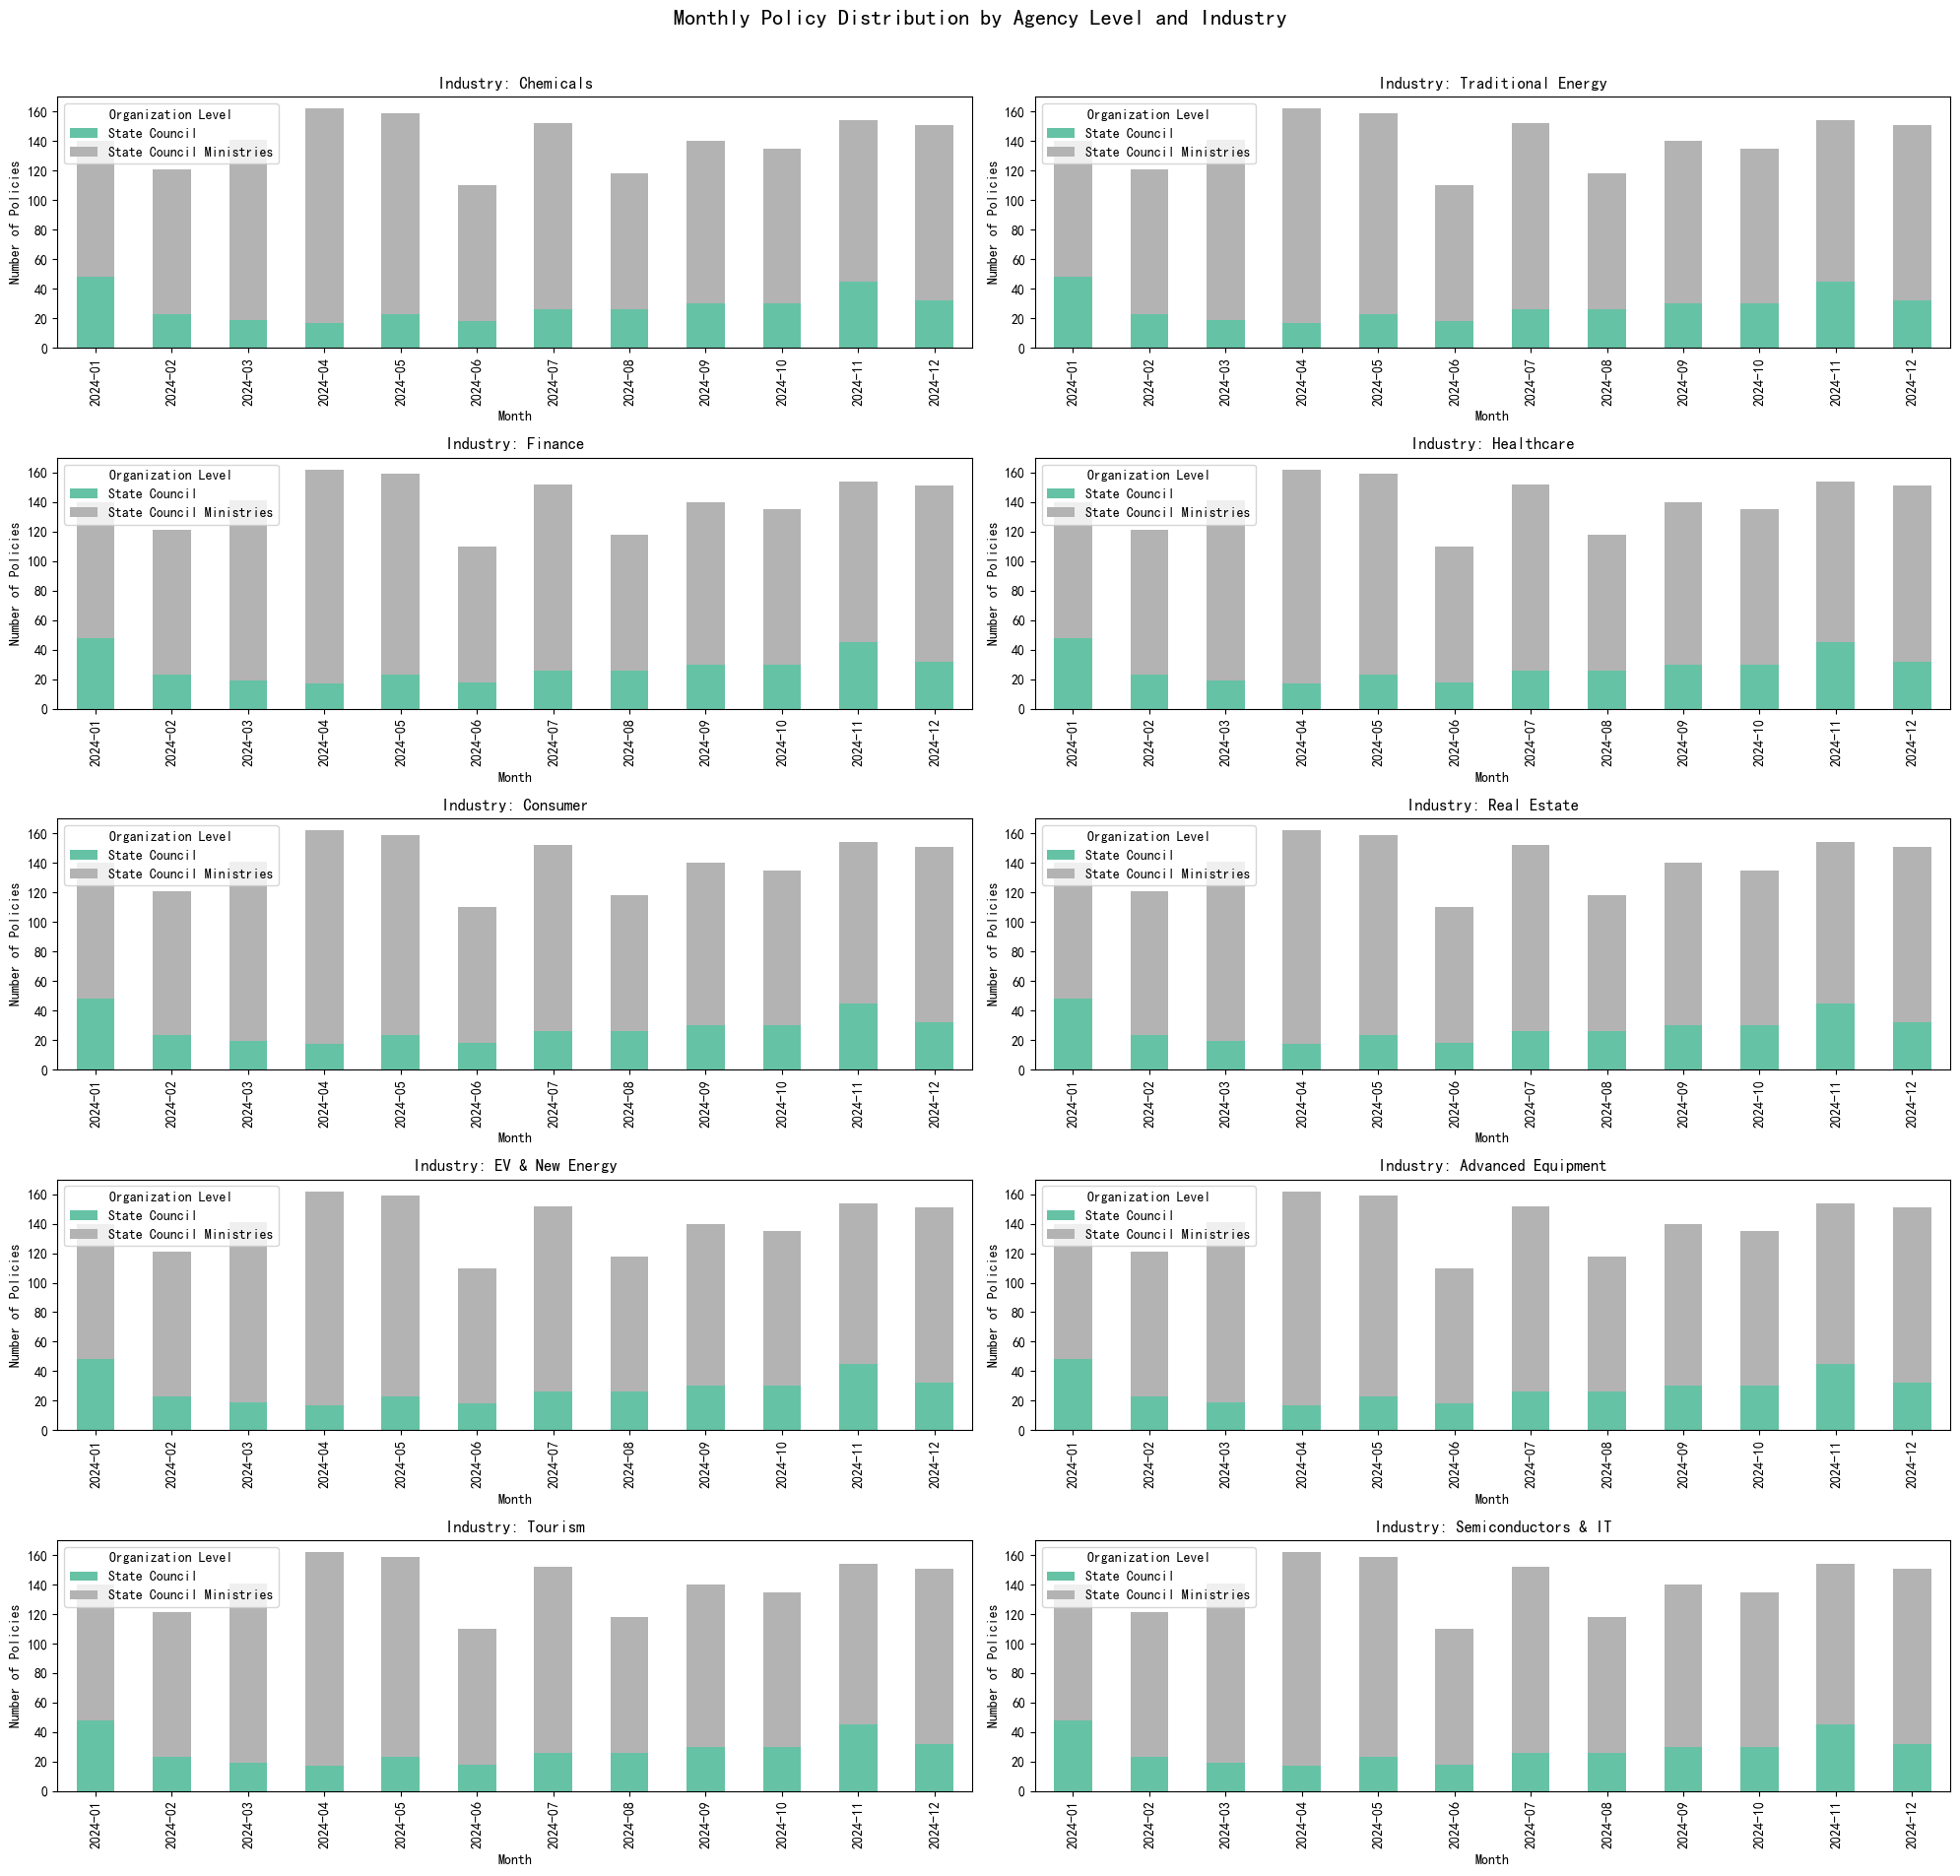

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv(r'C:\Users\wrz\Desktop\FYPProject\output.csv')

df['日期'] = pd.to_datetime(df['日期'], format='%Y.%m.%d')
df['月份'] = df['日期'].dt.to_period('M')

df['情感倾向'] = df['情感倾向'].replace({
    '正面': 'Positive',
    '中性': 'Neutral',
    '负面': 'Negative'
})


df['情感编码'] = df['情感倾向'].map({'Positive': 1, 'Neutral': 0, 'Negative': -1})


df['机关层级编码'] = df['机关层级'].map({'国务院': 1, '国务院部门': 2})


df['机关层级'] = df['机关层级'].replace({
    '国务院': 'State Council',
    '国务院部门': 'State Council Ministries'
})

df['影响行业'] = df['影响行业'].replace({
    '化工': 'Chemicals',
    '传统能源': 'Traditional Energy',
    '房地产': 'Real Estate',
    '金融': 'Finance',
    '消费': 'Consumer',
    '旅游': 'Tourism',
    '医药': 'Healthcare',
    '电动车新能源': 'EV & New Energy',
    '高端装备': 'Advanced Equipment',
    '半导体与信息技术': 'Semiconductors & IT'
})


policy_counts = df.drop_duplicates(subset=['标题']).groupby('月份').size()
plt.figure(figsize=(12, 6))
policy_counts.plot(kind='bar', color='skyblue')
plt.title('Monthly Number of Policies')
plt.xlabel('Month')
plt.ylabel('Number of Policies')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


plt.figure(figsize=(14, 8))
sns.countplot(data=df, x='月份', hue='情感倾向', palette='Set2')
plt.title('Monthly Number of Policies by Sentiment')
plt.xlabel('Month')
plt.ylabel('Number of Policies')
plt.xticks(rotation=45)
plt.legend(title='Sentiment')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


plt.figure(figsize=(12, 6))
sns.countplot(data=df.drop_duplicates(subset=['标题']), x='月份', hue='机关层级', palette='Paired')
plt.title('Monthly Number of Policies by Organization Level')
plt.xlabel('Month')
plt.ylabel('Number of Policies')
plt.xticks(rotation=45)
plt.legend(title='Organization Level')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


industries = df['影响行业'].dropna().unique()
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(20, 20))
fig.suptitle('Monthly Sentiment Distribution by Industry', fontsize=16)
axes = axes.flatten()

for i, industry in enumerate(industries):
    industry_df = df[df['影响行业'] == industry]
    sentiment_counts = industry_df.groupby(['月份', '情感倾向']).size().unstack().fillna(0)

    if not sentiment_counts.empty:
        sentiment_counts.plot(kind='bar', stacked=True, ax=axes[i])
        axes[i].set_title(f'Industry: {industry}')
        axes[i].set_xlabel('Month')
        axes[i].set_ylabel('Number of Policies')
        axes[i].legend(title='Sentiment')
    else:
        axes[i].set_visible(False)

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()


fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(20, 20))
fig.suptitle('Monthly Policy Distribution by Agency Level and Industry', fontsize=16)
axes = axes.flatten()

for i, industry in enumerate(industries):
    industry_df = df[df['影响行业'] == industry]
    org_counts = industry_df.groupby(['月份', '机关层级']).size().unstack().fillna(0)

    if not org_counts.empty:
        org_counts.plot(kind='bar', stacked=True, ax=axes[i], colormap='Set2')
        axes[i].set_title(f'Industry: {industry}')
        axes[i].set_xlabel('Month')
        axes[i].set_ylabel('Number of Policies')
        axes[i].legend(title='Organization Level')
    else:
        axes[i].set_visible(False)

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()


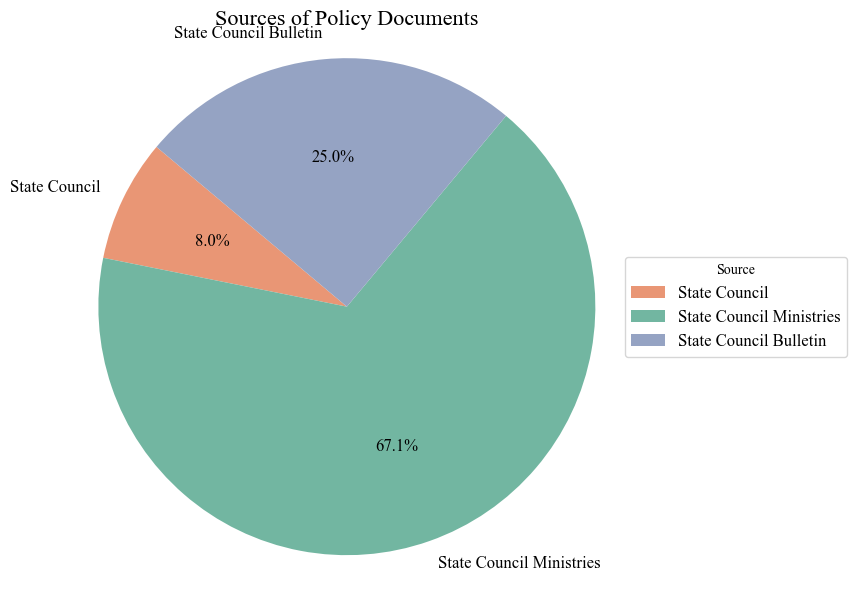

In [8]:
import matplotlib.pyplot as plt


labels = ['State Council', 'State Council Ministries', 'State Council Bulletin']
sizes = [134, 1129, 420]
colors = ['#e99675', '#72b6a1', '#95a3c3']


plt.figure(figsize=(8, 6))
wedges, texts, autotexts = plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=140,
    textprops={'fontsize': 12}
)


plt.title('Sources of Policy Documents', fontsize=16)


plt.legend(wedges, labels, title="Source", loc="center left", bbox_to_anchor=(1, 0.5), fontsize=12)


plt.axis('equal')

plt.tight_layout()
plt.show()


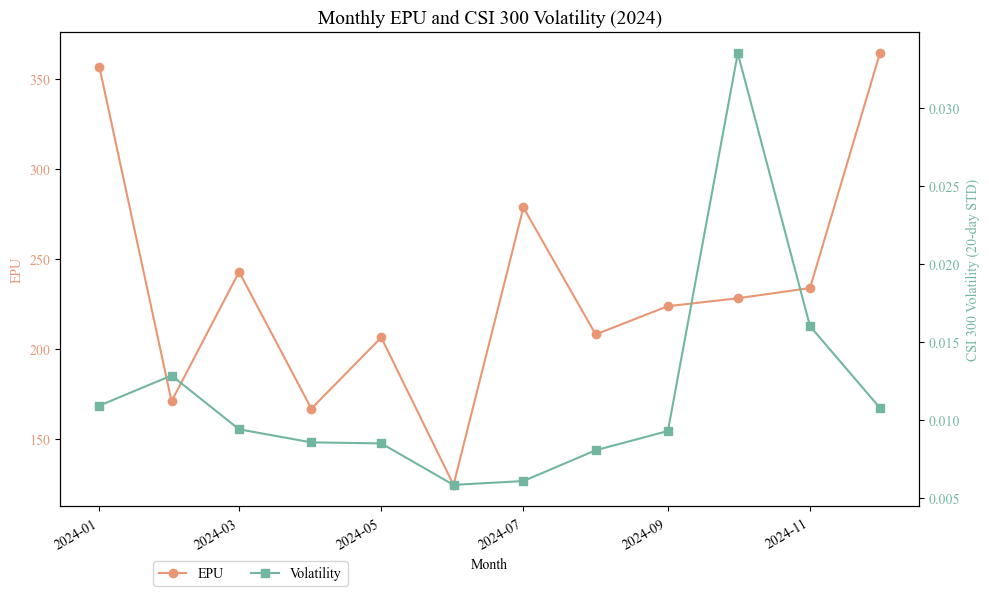

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df_csi300 = pd.read_csv(r'C:\Users\wrz\Desktop\FYPProject\Data\000300.SH.csv', parse_dates=['日期'])
df_csi300 = df_csi300.sort_values('日期')
df_csi300['return'] = df_csi300['收盘价(元)'].pct_change()
df_csi300['volatility'] = df_csi300['return'].rolling(window=20).std()


df_epu = pd.read_csv(r'C:\Users\wrz\Desktop\FYPProject\Data\China_EPU.csv')
df_epu['date'] = pd.to_datetime(df_epu[['year', 'month']].assign(day=1))


df_csi300['month'] = df_csi300['日期'].dt.to_period('M')
monthly_vol = df_csi300.groupby('month')['volatility'].mean().reset_index()
monthly_vol['month'] = monthly_vol['month'].dt.to_timestamp()


df_epu_2024 = df_epu[(df_epu['date'] >= '2024-01-01') & (df_epu['date'] <= '2024-12-31')]
monthly_vol_2024 = monthly_vol[(monthly_vol['month'] >= '2024-01-01') & (monthly_vol['month'] <= '2024-12-31')]
df_plot = pd.merge(monthly_vol_2024, df_epu_2024[['date', 'EPU']], left_on='month', right_on='date')


fig, ax1 = plt.subplots(figsize=(10, 6))


color_epu = '#e99675'
ax1.set_xlabel('Month')
ax1.set_ylabel('EPU', color=color_epu)
ax1.plot(df_plot['month'], df_plot['EPU'], color=color_epu, marker='o', label='EPU')
ax1.tick_params(axis='y', labelcolor=color_epu)


ax2 = ax1.twinx()
color_vol = '#72b6a1'
ax2.set_ylabel('CSI 300 Volatility (20-day STD)', color=color_vol)
ax2.plot(df_plot['month'], df_plot['volatility'], color=color_vol, marker='s', label='Volatility')
ax2.tick_params(axis='y', labelcolor=color_vol)


plt.title('Monthly EPU and CSI 300 Volatility (2024)', fontsize=14)
fig.autofmt_xdate()


lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
plt.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', bbox_to_anchor=(0.1, -0.1), ncol=2)

plt.tight_layout()
plt.show()


In [8]:
import pandas as pd
import numpy as np
from datetime import datetime
from scipy.stats import linregress
import matplotlib.pyplot as plt


df = pd.read_csv(r'C:\Users\wrz\Desktop\source.csv', encoding='gbk')


df.columns = df.columns.str.strip().str.replace('\ufeff', '')


df['日期'] = pd.to_datetime(df['日期'])
df = df.sort_values('日期').reset_index(drop=True)


df['总回报'] = df['总回报'].str.replace('%', '').astype(float) / 100
df['基准总回报'] = df['基准总回报'].str.replace('%', '').astype(float) / 100
df['区间回报'] = df['区间回报'].str.replace('%', '').astype(float) / 100
df['基准日回报'] = df['基准日回报'].str.replace('%', '').astype(float) / 100


absolute_return = df['总回报'].iloc[-1]


relative_return = df['总回报'].iloc[-1] - df['基准总回报'].iloc[-1]


days = (df['日期'].iloc[-1] - df['日期'].iloc[0]).days
cagr = (1 + df['总回报'].iloc[-1]) ** (365 / days) - 1


daily_win_rate = (df['区间回报'] > 0).mean()


df['周'] = df['日期'].dt.to_period('W')
weekly_returns = df.groupby('周')['区间回报'].sum()
weekly_win_rate = (weekly_returns > 0).mean()


df['月'] = df['日期'].dt.to_period('M')
monthly_returns = df.groupby('月')['区间回报'].sum()
monthly_win_rate = (monthly_returns > 0).mean()


slope, intercept, r_value, p_value, std_err = linregress(df['基准日回报'], df['区间回报'])
beta = slope
alpha = intercept * 252 


excess_return = df['区间回报']
sharpe_ratio = (excess_return.mean() / excess_return.std()) * np.sqrt(252)


df['累计净值'] = (1 + df['区间回报']).cumprod()
df['峰值'] = df['累计净值'].cummax()
df['回撤'] = (df['累计净值'] - df['峰值']) / df['峰值']
max_drawdown = df['回撤'].min()


print(f"绝对回报: {absolute_return:.2%}")
print(f"相对回报: {relative_return:.2%}")
print(f"年化收益率: {cagr:.2%}")
print(f"日胜率: {daily_win_rate:.2%}")
print(f"周胜率: {weekly_win_rate:.2%}")
print(f"月胜率: {monthly_win_rate:.2%}")
print(f"Alpha (年化): {alpha:.2%}")
print(f"Beta: {beta:.4f}")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
print(f"最大回撤: {max_drawdown:.2%}")


绝对回报: -12.43%
相对回报: -30.70%
年化收益率: -12.46%
日胜率: 28.22%
周胜率: 41.51%
月胜率: 41.67%
Alpha (年化): -4.69%
Beta: 1.1228
Sharpe Ratio: 0.37
最大回撤: -18.98%
